In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
np.random.seed(42)

n = 200

df = pd.DataFrame({
    "CGPA": np.round(
        np.random.uniform(5.5, 9.8, n),
        2
    ),

    "AptitudeScore": np.random.randint(
        40, 100, n
    ),

    "CommunicationScore": np.random.randint(
        40, 100, n
    ),

    "Internships": np.random.randint(
        0, 4, n
    ),

    "Projects": np.random.randint(
        0, 6, n
    ),

    "Department": np.random.choice(
        ["CSE", "IT", "ECE", "EEE"],
        n
    ),

    "Gender": np.random.choice(
        ["Male", "Female"],
        n
    )
})

df.head()

,CGPA,AptitudeScore,CommunicationScore,Internships,Projects,Department,Gender
0,7.11,63,97,0,2,CSE,Male
1,9.59,91,94,2,4,IT,Male
2,8.65,50,65,3,1,ECE,Male
3,8.07,88,76,0,0,EEE,Female
4,6.17,47,65,2,5,ECE,Female


In [3]:
df["PlacementScore"] = (
    df["CGPA"] * 10
    + df["AptitudeScore"] * 0.5
    + df["CommunicationScore"] * 0.3
    + df["Internships"] * 5
    + df["Projects"] * 2
)

In [4]:
df["PlacementStatus"] = np.where(
    df["PlacementScore"] >= 100,
    "Placed",
    "Not Placed"
)

In [5]:
print(df.head())

print("\nPlacement Status:")
print(df["PlacementStatus"].value_counts())

   CGPA  AptitudeScore  CommunicationScore  Internships  Projects Department  \
0  7.11             63                  97            0         2        CSE   
1  9.59             91                  94            2         4         IT   
2  8.65             50                  65            3         1        ECE   
3  8.07             88                  76            0         0        EEE   
4  6.17             47                  65            2         5        ECE   

   Gender  PlacementScore PlacementStatus  
0    Male           135.7          Placed  
1    Male           187.6          Placed  
2    Male           148.0          Placed  
3  Female           147.5          Placed  
4  Female           124.7          Placed  

Placement Status:
PlacementStatus
Placed    200
Name: count, dtype: int64


In [6]:
feature_cols = [
    "CGPA",
    "AptitudeScore",
    "CommunicationScore",
    "Internships",
    "Projects",
    "Department",
    "Gender"
]

X = df[feature_cols]

y = df["PlacementStatus"]

In [7]:
numeric_features = [
    "CGPA",
    "AptitudeScore",
    "CommunicationScore",
    "Internships",
    "Projects"
]

categorical_features = [
    "Department",
    "Gender"
]

In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

In [9]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

Training samples: 160
Validation samples: 40


In [10]:
dt_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            DecisionTreeClassifier(
                criterion="gini",
                random_state=42
            )
        )
    ]
)

In [11]:
dt_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                                  ['CGPA', 'AptitudeScore',
                                                   'CommunicationScore',
                                                   'Internships', 'Projects']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Department', 'Gender'])])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

In [12]:
dt_train_pred = dt_model.predict(X_train)
dt_val_pred = dt_model.predict(X_val)

In [13]:
dt_train_acc = accuracy_score(
    y_train,
    dt_train_pred
)

dt_val_acc = accuracy_score(
    y_val,
    dt_val_pred
)

print("Decision Tree Train Accuracy:",
      dt_train_acc)

print("Decision Tree Validation Accuracy:",
      dt_val_acc)

Decision Tree Train Accuracy: 1.0
Decision Tree Validation Accuracy: 1.0


In [14]:
rf_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                criterion="gini",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [15]:
rf_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                                  ['CGPA', 'AptitudeScore',
                                                   'CommunicationScore',
                                                   'Internships', 'Projects']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Department', 'Gender'])])),
                ('classifier',
                 RandomForestClassifier(n_jobs=-1, random_state=42))])

In [16]:
rf_train_pred = rf_model.predict(X_train)
rf_val_pred = rf_model.predict(X_val)

In [17]:
rf_train_acc = accuracy_score(
    y_train,
    rf_train_pred
)

rf_val_acc = accuracy_score(
    y_val,
    rf_val_pred
)

print("Random Forest Train Accuracy:",
      rf_train_acc)

print("Random Forest Validation Accuracy:",
      rf_val_acc)

Random Forest Train Accuracy: 1.0
Random Forest Validation Accuracy: 1.0


In [18]:
print("========== RANDOM FOREST CLASSIFICATION REPORT ==========")

print(
    classification_report(
        y_val,
        rf_val_pred,
        zero_division=0
    )
)

========== RANDOM FOREST CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

      Placed       1.00      1.00      1.00        40

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



In [19]:
comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest"
    ],

    "Train Accuracy": [
        dt_train_acc,
        rf_train_acc
    ],

    "Validation Accuracy": [
        dt_val_acc,
        rf_val_acc
    ]
})

print(comparison)

           Model  Train Accuracy  Validation Accuracy
0  Decision Tree             1.0                  1.0
1  Random Forest             1.0                  1.0


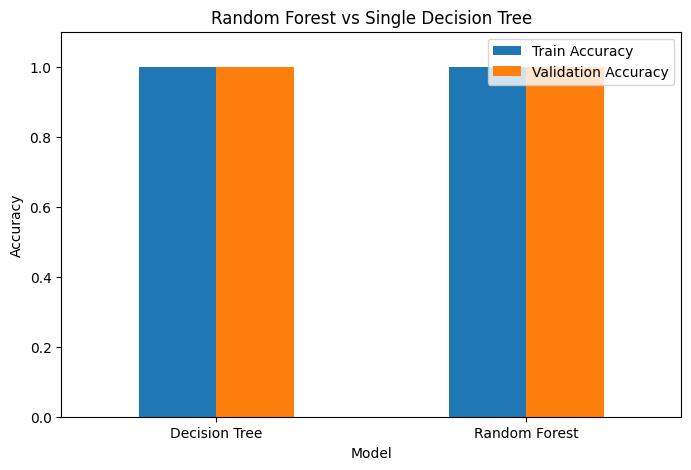

In [20]:
comparison.plot(
    x="Model",
    y=[
        "Train Accuracy",
        "Validation Accuracy"
    ],
    kind="bar",
    figsize=(8, 5)
)

plt.title("Random Forest vs Single Decision Tree")
plt.ylabel("Accuracy")
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.show()

In [21]:
rf_oob = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                oob_score=True,
                bootstrap=True,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [22]:
rf_oob.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                                  ['CGPA', 'AptitudeScore',
                                                   'CommunicationScore',
                                                   'Internships', 'Projects']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Department', 'Gender'])])),
                ('classifier',
                 RandomForestClassifier(n_jobs=-1, oob_score=True,
                                        random_state=42))])

In [23]:
oob_accuracy = (
    rf_oob
    .named_steps["classifier"]
    .oob_score_
)

print("OOB Accuracy:",
      oob_accuracy)

print("OOB Error:",
      1 - oob_accuracy)

OOB Accuracy: 1.0
OOB Error: 0.0


In [24]:
n_estimators_values = [
    10,
    20,
    30,
    50,
    75,
    100,
    150,
    200
]

In [25]:
oob_results = []

for n_trees in n_estimators_values:

    model = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "classifier",
                RandomForestClassifier(
                    n_estimators=n_trees,
                    oob_score=True,
                    bootstrap=True,
                    random_state=42,
                    n_jobs=-1
                )
            )
        ]
    )

    model.fit(
        X_train,
        y_train
    )

    oob_acc = (
        model
        .named_steps["classifier"]
        .oob_score_
    )

    oob_results.append({
        "n_estimators": n_trees,
        "OOB_accuracy": oob_acc,
        "OOB_error": 1 - oob_acc
    })

oob_df = pd.DataFrame(
    oob_results
)

oob_df

,n_estimators,OOB_accuracy,OOB_error
0,10,1.0,0.0
1,20,1.0,0.0
2,30,1.0,0.0
3,50,1.0,0.0
4,75,1.0,0.0
5,100,1.0,0.0
6,150,1.0,0.0
7,200,1.0,0.0


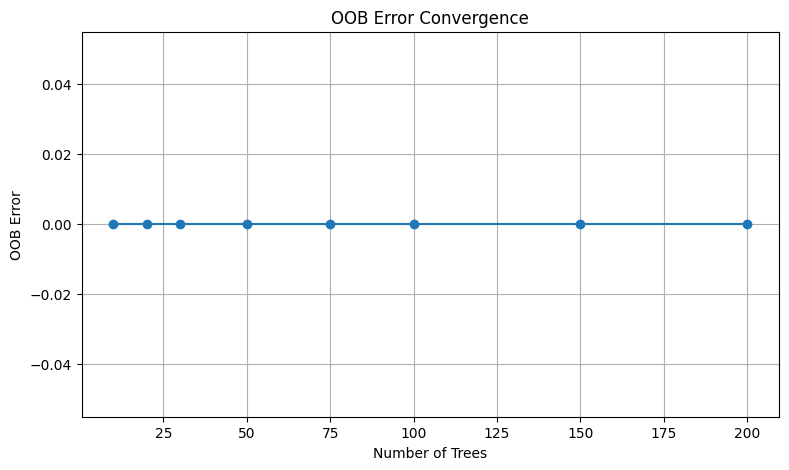

In [26]:
plt.figure(figsize=(9, 5))

plt.plot(
    oob_df["n_estimators"],
    oob_df["OOB_error"],
    marker="o"
)

plt.xlabel("Number of Trees")
plt.ylabel("OOB Error")
plt.title("OOB Error Convergence")

plt.grid(True)

plt.show()

In [27]:
max_features_values = [
    "sqrt",
    "log2",
    None
]

max_features_results = []

for value in max_features_values:

    model = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "classifier",
                RandomForestClassifier(
                    n_estimators=100,
                    max_features=value,
                    random_state=42,
                    n_jobs=-1
                )
            )
        ]
    )

    model.fit(
        X_train,
        y_train
    )

    pred = model.predict(
        X_val
    )

    acc = accuracy_score(
        y_val,
        pred
    )

    max_features_results.append({
        "max_features": str(value),
        "validation_accuracy": acc
    })

max_features_df = pd.DataFrame(
    max_features_results
)

max_features_df

,max_features,validation_accuracy
0,sqrt,1.0
1,log2,1.0
2,None,1.0


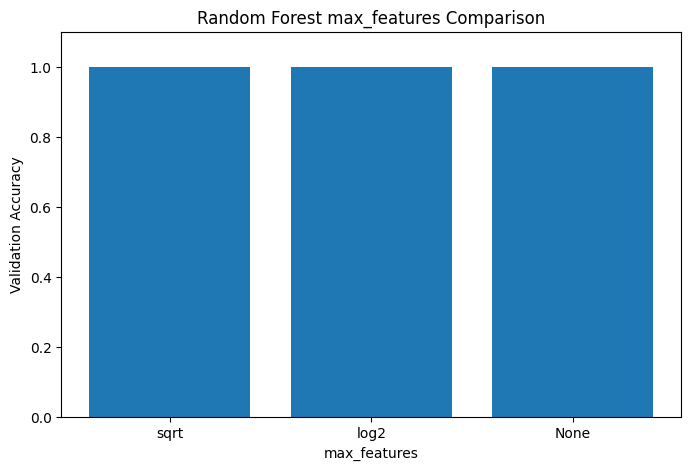

In [28]:
plt.figure(figsize=(8, 5))

plt.bar(
    max_features_df["max_features"],
    max_features_df["validation_accuracy"]
)

plt.xlabel("max_features")
plt.ylabel("Validation Accuracy")
plt.title("Random Forest max_features Comparison")

plt.ylim(0, 1.1)

plt.show()

In [29]:
X_train_processed = preprocessor.fit_transform(
    X_train
)

X_val_processed = preprocessor.transform(
    X_val
)

print(
    "Processed training shape:",
    X_train_processed.shape
)

Processed training shape: (160, 11)


In [30]:
rng = np.random.default_rng(42)

n_samples = len(X_train)

bootstrap_models = []

bootstrap_predictions = []

for i in range(5):

    indices = rng.choice(
        n_samples,
        size=n_samples,
        replace=True
    )

    X_bootstrap = X_train_processed[
        indices
    ]

    y_bootstrap = y_train.iloc[
        indices
    ]

    tree = DecisionTreeClassifier(
        random_state=i
    )

    tree.fit(
        X_bootstrap,
        y_bootstrap
    )

    prediction = tree.predict(
        X_val_processed
    )

    bootstrap_models.append(
        tree
    )

    bootstrap_predictions.append(
        prediction
    )

print(
    "Number of bootstrap trees:",
    len(bootstrap_models)
)

Number of bootstrap trees: 5


In [31]:
bootstrap_predictions = np.array(
    bootstrap_predictions
)

print(
    "Prediction shape:",
    bootstrap_predictions.shape
)

Prediction shape: (5, 40)


In [32]:
final_predictions = []

for column in bootstrap_predictions.T:

    values, counts = np.unique(
        column,
        return_counts=True
    )

    majority_vote = values[
        np.argmax(counts)
    ]

    final_predictions.append(
        majority_vote
    )

In [33]:
manual_bagging_acc = accuracy_score(
    y_val,
    final_predictions
)

print(
    "Manual Bootstrap Bagging Accuracy:",
    manual_bagging_acc
)

Manual Bootstrap Bagging Accuracy: 1.0


In [34]:
rf_importance = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_importance.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                                  ['CGPA', 'AptitudeScore',
                                                   'CommunicationScore',
                                                   'Internships', 'Projects']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Department', 'Gender'])])),
                ('classifier',
                 RandomForestClassifier(n_jobs=-1, random_state=42))])

In [35]:
perm_result = permutation_importance(
    rf_importance,
    X_val,
    y_val,
    n_repeats=10,
    random_state=42,
    scoring="accuracy"
)

In [36]:
importance_df = pd.DataFrame({
    "Feature": X_val.columns,
    "Importance": perm_result.importances_mean
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

print(importance_df)

              Feature  Importance
0                CGPA         0.0
1       AptitudeScore         0.0
2  CommunicationScore         0.0
3         Internships         0.0
4            Projects         0.0
5          Department         0.0
6              Gender         0.0


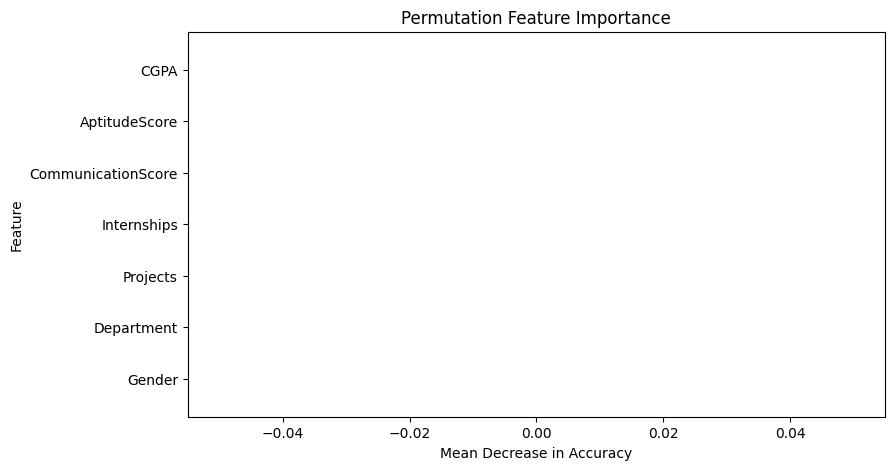

In [37]:
plt.figure(figsize=(9, 5))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel(
    "Mean Decrease in Accuracy"
)

plt.ylabel("Feature")

plt.title(
    "Permutation Feature Importance"
)

plt.gca().invert_yaxis()

plt.show()

In [38]:
def rf_vs_single_tree(
    X_train,
    y_train,
    X_val,
    y_val,
    n_estimators_list
):

    results = []

    # Single Decision Tree
    dt_model = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "classifier",
                DecisionTreeClassifier(
                    criterion="gini",
                    random_state=42
                )
            )
        ]
    )

    dt_model.fit(
        X_train,
        y_train
    )

    dt_pred = dt_model.predict(
        X_val
    )

    dt_acc = accuracy_score(
        y_val,
        dt_pred
    )

    # Random Forest for different numbers of trees
    for n_trees in n_estimators_list:

        rf_model = Pipeline(
            steps=[
                (
                    "preprocessor",
                    preprocessor
                ),
                (
                    "classifier",
                    RandomForestClassifier(
                        n_estimators=n_trees,
                        criterion="gini",
                        oob_score=True,
                        bootstrap=True,
                        random_state=42,
                        n_jobs=-1
                    )
                )
            ]
        )

        rf_model.fit(
            X_train,
            y_train
        )

        rf_pred = rf_model.predict(
            X_val
        )

        rf_acc = accuracy_score(
            y_val,
            rf_pred
        )

        oob_acc = (
            rf_model
            .named_steps["classifier"]
            .oob_score_
        )

        results.append({
            "n_estimators": n_trees,
            "RF_val_acc": rf_acc,
            "DT_val_acc": dt_acc,
            "OOB_acc": oob_acc
        })

    results_df = pd.DataFrame(
        results
    )

    # Plot 3 lines
    plt.figure(figsize=(10, 6))

    plt.plot(
        results_df["n_estimators"],
        results_df["RF_val_acc"],
        marker="o",
        label="Random Forest Validation Accuracy"
    )

    plt.plot(
        results_df["n_estimators"],
        results_df["DT_val_acc"],
        marker="s",
        label="Decision Tree Validation Accuracy"
    )

    plt.plot(
        results_df["n_estimators"],
        results_df["OOB_acc"],
        marker="^",
        label="OOB Accuracy"
    )

    plt.xlabel("Number of Estimators")
    plt.ylabel("Accuracy")
    plt.title(
        "Random Forest vs Single Decision Tree"
    )

    plt.legend()
    plt.grid(True)

    plt.show()

    return results_df

In [39]:
n_estimators_list = [
    10,
    20,
    50,
    75,
    100,
    150,
    200
]

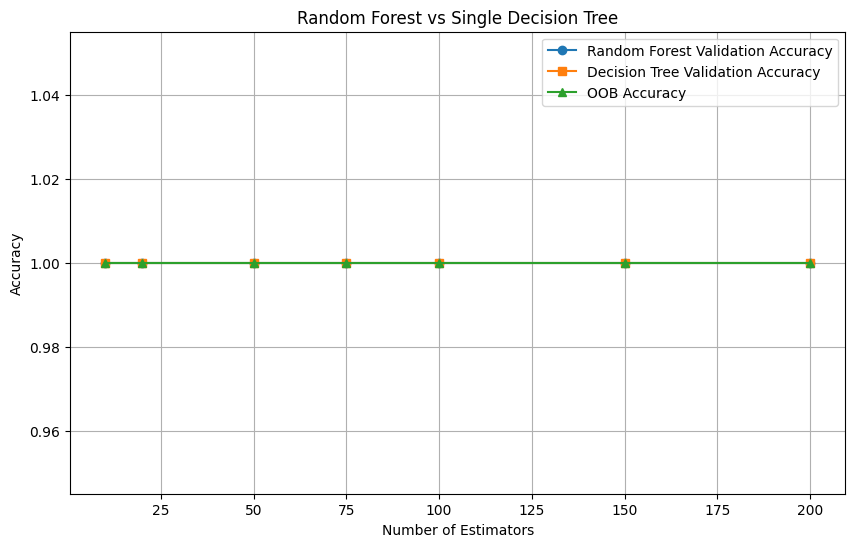

In [40]:
rf_results = rf_vs_single_tree(
    X_train,
    y_train,
    X_val,
    y_val,
    n_estimators_list
)

In [41]:
rf_results

,n_estimators,RF_val_acc,DT_val_acc,OOB_acc
0,10,1.0,1.0,1.0
1,20,1.0,1.0,1.0
2,50,1.0,1.0,1.0
3,75,1.0,1.0,1.0
4,100,1.0,1.0,1.0
5,150,1.0,1.0,1.0
6,200,1.0,1.0,1.0


In [42]:
best_rf_row = rf_results.loc[
    rf_results["RF_val_acc"].idxmax()
]

print(
    "========== BEST RANDOM FOREST RESULT =========="
)

print(best_rf_row)

========== BEST RANDOM FOREST RESULT ==========
n_estimators    10.0
RF_val_acc       1.0
DT_val_acc       1.0
OOB_acc          1.0
Name: 0, dtype: float64


In [43]:
final_rf = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                criterion="gini",
                oob_score=True,
                bootstrap=True,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [44]:
final_rf.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                                  ['CGPA', 'AptitudeScore',
                                                   'CommunicationScore',
                                                   'Internships', 'Projects']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Department', 'Gender'])])),
                ('classifier',
                 RandomForestClassifier(n_jobs=-1, oob_score=True,
                                        random_state=42))])

In [45]:
final_rf_pred = final_rf.predict(
    X_val
)

In [46]:
final_rf_acc = accuracy_score(
    y_val,
    final_rf_pred
)

print(
    "Final Random Forest Validation Accuracy:",
    final_rf_acc
)

Final Random Forest Validation Accuracy: 1.0


In [47]:
final_oob_acc = (
    final_rf
    .named_steps["classifier"]
    .oob_score_
)

print(
    "Final OOB Accuracy:",
    final_oob_acc
)

print(
    "Final OOB Error:",
    1 - final_oob_acc
)

Final OOB Accuracy: 1.0
Final OOB Error: 0.0


In [48]:
print(
    "========== FINAL RANDOM FOREST REPORT =========="
)

print(
    classification_report(
        y_val,
        final_rf_pred,
        zero_division=0
    )
)

========== FINAL RANDOM FOREST REPORT ==========
              precision    recall  f1-score   support

      Placed       1.00      1.00      1.00        40

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


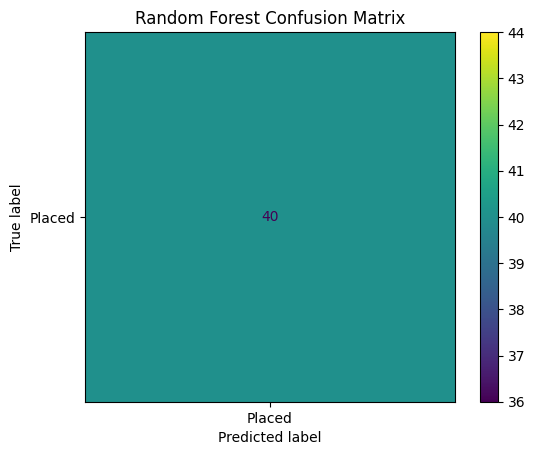

In [49]:
ConfusionMatrixDisplay.from_predictions(
    y_val,
    final_rf_pred
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.show()